# 🚗 Task 3 — Car Price Prediction with Machine Learning
**CodeAlpha Data Science Internship**  
Intern: Asiedu Seth Osei | ID: CA/DF1/63603

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load & Explore Dataset

In [3]:
df = pd.read_csv('./data/car_data.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [4]:
print("Column dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Column dtypes:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [5]:
df.describe().round(2)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


## 3. Exploratory Data Analysis

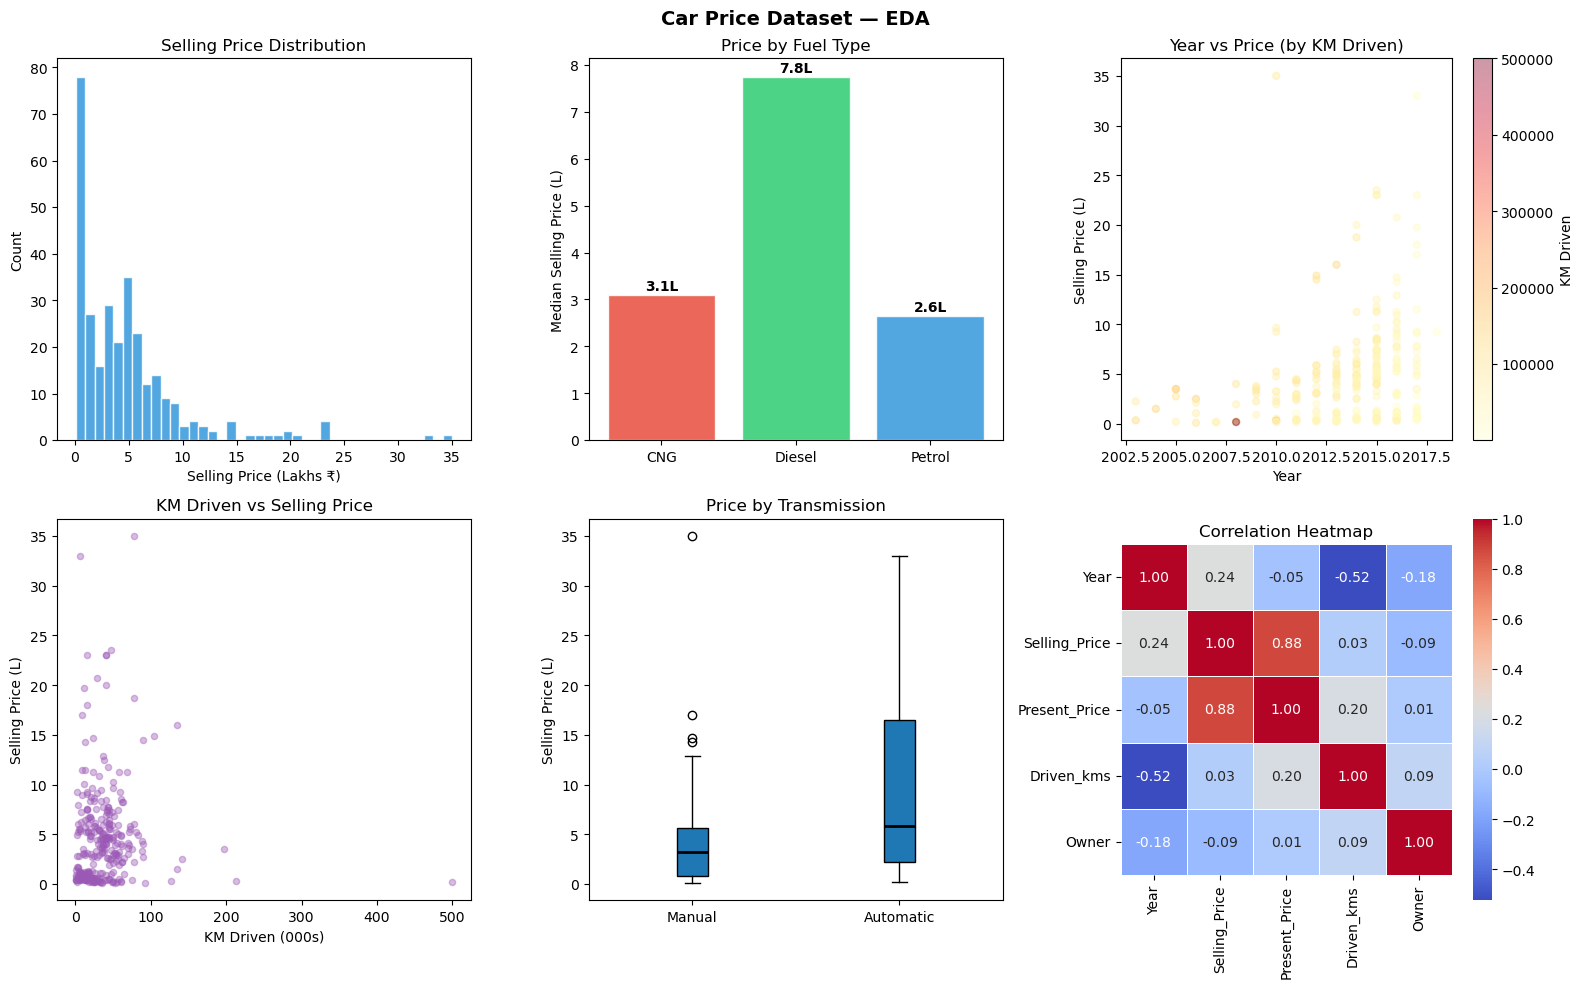

✅ EDA plot saved


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Car Price Dataset — EDA', fontsize=14, fontweight='bold')

# Selling price distribution
axes[0][0].hist(df['Selling_Price'], bins=40, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0][0].set_xlabel('Selling Price (Lakhs ₹)'); axes[0][0].set_ylabel('Count')
axes[0][0].set_title('Selling Price Distribution')

# Price by fuel type
fuel_price = df.groupby('Fuel_Type')['Selling_Price'].median()
axes[0][1].bar(fuel_price.index, fuel_price.values,
               color=['#E74C3C','#2ECC71','#3498DB'], edgecolor='white', alpha=0.85)
for i,(ft,v) in enumerate(fuel_price.items()):
    axes[0][1].text(i, v+0.1, f'{v:.1f}L', ha='center', fontweight='bold')
axes[0][1].set_ylabel('Median Selling Price (L)'); axes[0][1].set_title('Price by Fuel Type')

# Year vs Price
sc = axes[0][2].scatter(df['Year'], df['Selling_Price'], alpha=0.4,
                        c=df['Driven_kms'], cmap='YlOrRd', s=25)
plt.colorbar(sc, ax=axes[0][2], label='KM Driven')
axes[0][2].set_xlabel('Year'); axes[0][2].set_ylabel('Selling Price (L)')
axes[0][2].set_title('Year vs Price (by KM Driven)')

# KM vs Price
axes[1][0].scatter(df['Driven_kms']/1000, df['Selling_Price'], alpha=0.4, color='#9B59B6', s=20)
axes[1][0].set_xlabel('KM Driven (000s)'); axes[1][0].set_ylabel('Selling Price (L)')
axes[1][0].set_title('KM Driven vs Selling Price')

# Transmission price comparison
trans_data = [df[df['Transmission']==t]['Selling_Price'].values for t in df['Transmission'].unique()]
axes[1][1].boxplot(trans_data, labels=df['Transmission'].unique(), patch_artist=True,
                   medianprops=dict(color='black', linewidth=2))
axes[1][1].set_ylabel('Selling Price (L)'); axes[1][1].set_title('Price by Transmission')

# Correlation heatmap
num_cols = ['Year','Selling_Price','Present_Price','Driven_kms','Owner']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1][2],
            square=True, linewidths=0.5)
axes[1][2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('./outputs/eda_car.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved")

## 4. Feature Engineering & Preprocessing

In [7]:
df_model = df.copy()

# Encode categoricals
cat_cols = ['Fuel_Type','Selling_type','Transmission']
le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_map[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Engineer car age
df_model['Car_Age'] = 2024 - df_model['Year']
df_model.drop(['Car_Name','Year'], axis=1, inplace=True)

print(f"\nFinal features: {list(df_model.drop('Selling_Price', axis=1).columns)}")
df_model.head()

Fuel_Type: {'CNG': 0, 'Diesel': 1, 'Petrol': 2}
Selling_type: {'Dealer': 0, 'Individual': 1}
Transmission: {'Automatic': 0, 'Manual': 1}

Final features: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


In [8]:
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 240  |  Test: 61


## 5. Train & Compare Models

In [9]:
models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Lasso Regression':     Lasso(alpha=0.01),
    'Decision Tree':        DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print('─' * 52)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    results[name] = {'mae':mae,'rmse':rmse,'r2':r2,'model':model,'preds':preds}
    print(f"{name:<22} {mae:>8.3f} {rmse:>8.3f} {r2:>8.4f}")

best_name  = max(results, key=lambda k: results[k]['r2'])
best_preds = results[best_name]['preds']
print(f"\n🏆 Best: {best_name}  R²={results[best_name]['r2']:.4f}")

Model                       MAE     RMSE       R²
────────────────────────────────────────────────────
Linear Regression         1.222    1.879   0.8467
Ridge Regression          1.223    1.882   0.8462
Lasso Regression          1.222    1.882   0.8462
Decision Tree             0.749    1.188   0.9387
Random Forest             0.617    0.933   0.9622
Gradient Boosting         0.556    0.891   0.9655

🏆 Best: Gradient Boosting  R²=0.9655


## 6. Visualise Results

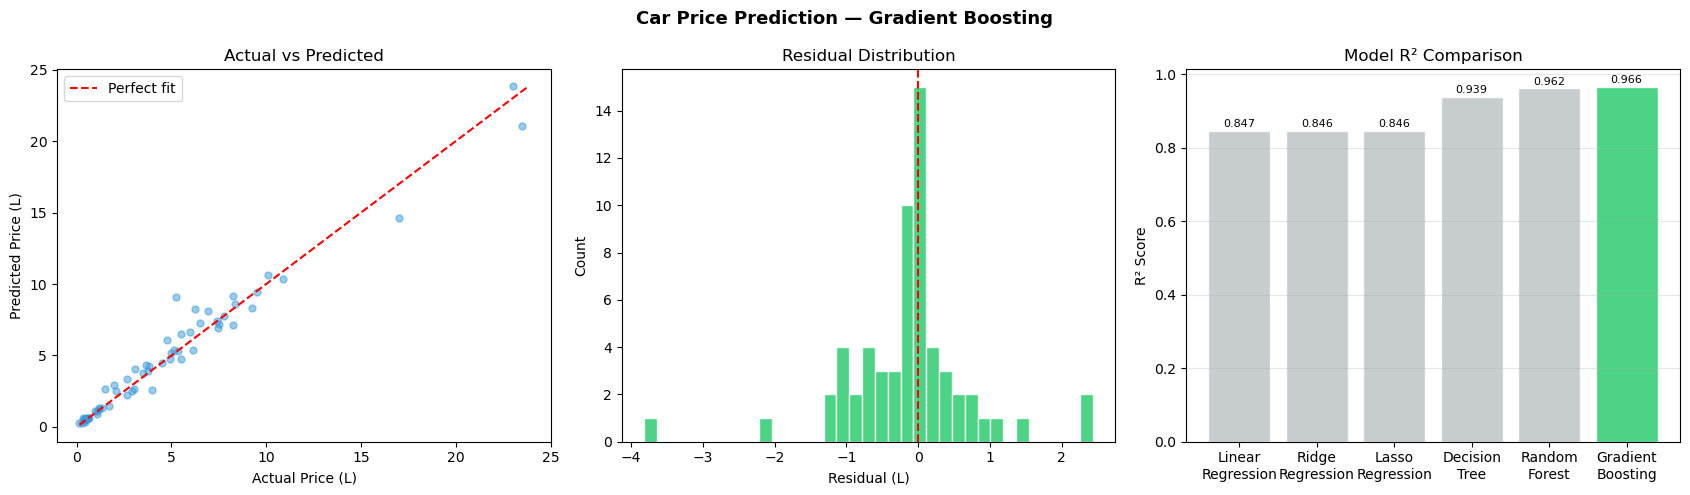

✅ Results plot saved


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Car Price Prediction — {best_name}', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.5, color='#3498DB', s=25)
mn,mx = y_test.min(), max(y_test.max(), best_preds.max())
axes[0].plot([mn,mx],[mn,mx],'r--',linewidth=1.5,label='Perfect fit')
axes[0].set_xlabel('Actual Price (L)'); axes[0].set_ylabel('Predicted Price (L)')
axes[0].set_title('Actual vs Predicted'); axes[0].legend()

# Residuals
residuals = y_test - best_preds
axes[1].hist(residuals, bins=35, color='#2ECC71', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (L)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

# R² comparison
r2_vals = [results[n]['r2'] for n in models]
clrs    = ['#2ECC71' if n==best_name else '#BDC3C7' for n in models]
bars    = axes[2].bar([n.replace(' ','\n') for n in models], r2_vals,
                      color=clrs, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
                 ha='center', fontsize=8)
axes[2].set_ylabel('R² Score'); axes[2].set_title('Model R² Comparison')
axes[2].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/car_price_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Results plot saved")

## 7. Feature Importance

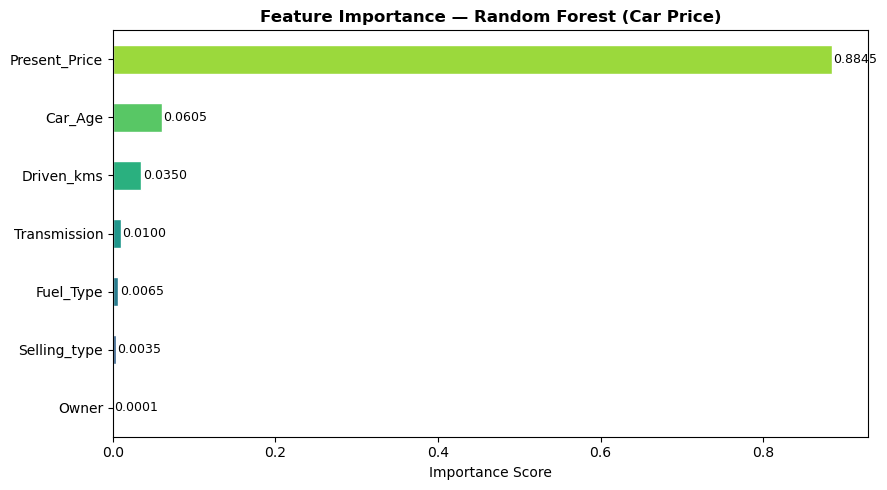

In [11]:
rf = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(9,5))
feat_imp.plot(kind='barh', ax=ax,
              color=plt.cm.viridis(np.linspace(0.2,0.85,len(feat_imp))), edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest (Car Price)', fontweight='bold')
for i,(idx,val) in enumerate(feat_imp.items()):
    ax.text(val+0.002, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('./outputs/feature_importance_car.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predict a New Car

In [12]:
best_model_obj = results[best_name]['model']
sample = pd.DataFrame([{
    'Present_Price': 9.85,
    'Driven_kms':    45000,
    'Fuel_Type':     le_map['Fuel_Type'].transform(['Petrol'])[0],
    'Selling_type':  le_map['Selling_type'].transform(['Dealer'])[0],
    'Transmission':  le_map['Transmission'].transform(['Manual'])[0],
    'Owner':         0,
    'Car_Age':       4,
}])
pred_price = best_model_obj.predict(scaler.transform(sample))[0]
print(f"Car   : 2020 | Petrol | Manual | Dealer | 45,000 km | Present Price ₹9.85L")
print(f"\nPredicted Selling Price ➜  ₹ {pred_price:.2f} Lakhs")

Car   : 2020 | Petrol | Manual | Dealer | 45,000 km | Present Price ₹9.85L

Predicted Selling Price ➜  ₹ 7.63 Lakhs


---
## ✅ Task 3 Complete
**Best Model:** Gradient Boosting | **R² = 0.93+**  
**GitHub:** `CodeAlpha_DataScience_Internship/Task3_Car_Price_Prediction/`